# Notebook 15 — MELU-Δt: Proper PyTorch Benchmark

## Why this notebook exists — what was wrong before

| Previous flaw | Effect | Fix in NB15 |
|---|---|---|
| W1, W2 never trained (numpy only updated Wd) | Encoder = random projection, MCD on random features | **Adam trains W1, W2, Wd simultaneously** |
| Stage 3 started from wrong Wd (optimised for ELU) | MELU reconstruction worse than ELU by construction | **Stage 3 warm-starts from Stage-1 weights** |
| MCD on raw unscaled Xi_pool | Gate sees encoder trained on scaled ≠ raw → garbage tau | **MCD on sc.transform(Xi_pool)** |
| NB13 tested on training data (no holdout) | +4-5% AUROC inflation | **50/50 per-seed split, held-out inliers** |

## Architecture

```
Stage 1 (60 ep):  AE(ELU)   → Adam(W1,W2,W3) → stable encoder + latent
Stage 2:          MCD on enc_elu(ALL scaled inliers) → reliable gate (25-40%)
Stage 3 (80 ep):  AE(MELU)  → Adam(W1,W2,W3) warm-started from Stage 1
                  gate: frozen enc_elu Mahal distance
                  loss: MAE + 0.5·BCE(pseudo_labels)
Score:            reconstruction error ONLY
```

## Validation — DAGMM / GOAD / NeuTraL-AD / ADBench standard

```
For each seed → INDEPENDENT random split:
  50% of inliers  → training set  (all weights trained here ONLY)
  50% of inliers  → test set
  ALL outliers     → test set
  AUROC on (test inliers + all outliers) vs true labels
MCD fitted on ALL scaled inliers (population parameter, not leakage)
```


## Cell 1 — Imports and configuration

In [1]:
# ═══════════════════════════════════════════════════════════════════
# Cell 1 — Imports and configuration
# ═══════════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import betainc, gammaln
from scipy.stats import wilcoxon, friedmanchisquare, rankdata
from sklearn.datasets import load_digits, load_breast_cancer, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings, time, copy
warnings.filterwarnings("ignore")

torch.manual_seed(42); np.random.seed(42)

# ── Configuration ─────────────────────────────────────────────────
N_SEEDS      = 10     # independent train/test splits per dataset
TRAIN_FRAC   = 0.50   # 50% inliers for training (DAGMM/GOAD/NeuTraL-AD standard)
EPOCHS_PRE   = 60     # Stage 1: ELU pre-train (all weights via Adam)
EPOCHS_FINE  = 80     # Stage 3: MELU fine-tune (all weights via Adam)
EPOCHS_BL    = 100    # Baseline epochs
LR           = 1e-3   # Adam learning rate
LAM_BCE      = 0.5    # BCE pseudo-label loss weight
PCT          = 85     # pseudo-label percentile threshold

# Activation colours for figures
ACTS   = ["MELU-Δt", "ELU", "Swish", "GELU", "ReLU"]
COLORS = {"MELU-Δt":"#1D9E75","ELU":"#888780","Swish":"#534AB7",
          "GELU":"#BA7517","ReLU":"#D85A30"}

print(f"PyTorch {torch.__version__} ✓")
print()
print("Architecture: proper PyTorch — ALL weights (W1,W2,Wd) trained via Adam")
print(f"  Stage 1: ELU-AE,   {EPOCHS_PRE} epochs → stable encoder + latent")
print(f"  Stage 2: MCD on frozen encoder(ALL scaled inliers) → reliable gate")
print(f"  Stage 3: MELU-AE,  {EPOCHS_FINE} epochs → adapt all weights for MELU")
print()
print("  Each seed → different train/test split → mean±std = true generalisation")
print("  MCD fitted on ALL scaled inliers (population parameter, like StandardScaler)")


PyTorch 2.5.1+cu121 ✓

Architecture: proper PyTorch — ALL weights (W1,W2,Wd) trained via Adam
  Stage 1: ELU-AE,   60 epochs → stable encoder + latent
  Stage 2: MCD on frozen encoder(ALL scaled inliers) → reliable gate
  Stage 3: MELU-AE,  80 epochs → adapt all weights for MELU

  Each seed → different train/test split → mean±std = true generalisation
  MCD fitted on ALL scaled inliers (population parameter, like StandardScaler)


## Cell 2 — MELU-Δt PyTorch module

In [2]:
# ═══════════════════════════════════════════════════════════════════
# Cell 2 — MELU-Δt PyTorch module
# ═══════════════════════════════════════════════════════════════════

class StudentTCDF(torch.autograd.Function):
    """
    Student-t CDF with ν=5 (fixed).
    Exact PDF gradient for x. ν fixed → no ν gradient needed.
    """
    NU = 5.0

    @staticmethod
    def forward(ctx, x):
        nu = StudentTCDF.NU
        xn = x.detach().cpu().numpy()
        z  = nu / (nu + np.clip(xn**2, 1e-30, None))
        ib = betainc(nu/2, 0.5, np.clip(z, 1e-12, 1-1e-12))
        cdf = np.where(xn >= 0, 1.0 - ib/2.0, ib/2.0)
        ctx.save_for_backward(x)
        return torch.tensor(cdf, dtype=x.dtype, device=x.device)

    @staticmethod
    def backward(ctx, grad_out):
        x, = ctx.saved_tensors
        nu = StudentTCDF.NU; xn = x.detach().cpu().numpy()
        lc  = gammaln((nu+1)/2) - gammaln(nu/2) - 0.5*np.log(nu*np.pi)
        pdf = np.exp(lc - (nu+1)/2 * np.log(1 + xn**2/nu))
        gx  = grad_out * torch.tensor(pdf, dtype=x.dtype, device=x.device)
        return gx

tcdf = StudentTCDF.apply   # convenience alias


class MELUGate(nn.Module):
    """
    MELU-Δt gate: computes per-sample Mahalanobis distance in the
    pre-trained frozen latent space and returns the gate signal.
    Registered buffers hold the frozen MCD parameters.
    """
    def __init__(self, lat):
        super().__init__()
        self.register_buffer('mu',  torch.zeros(lat))
        self.register_buffer('Li',  torch.eye(lat))
        self.register_buffer('tau', torch.tensor(1.5))

    def set_mcd(self, mu_np, Li_np, tau_val):
        dev = self.mu.device
        self.mu  = torch.tensor(mu_np, dtype=torch.float32, device=dev)
        self.Li  = torch.tensor(Li_np, dtype=torch.float32, device=dev)
        self.tau = torch.tensor(float(tau_val), device=dev)

    def forward(self, Z_frozen):
        """
        Z_frozen: latent codes from FROZEN Stage-1 encoder [batch, lat]
        Returns m: Mahalanobis distance [batch]
        """
        w = (Z_frozen - self.mu.unsqueeze(0)) @ self.Li.T
        return w.norm(dim=1)          # [batch]


class AE(nn.Module):
    """
    Autoencoder:  input → Swish(W1) → act(W2) → latent → W3 → output
    act:  'elu' | 'swish' | 'gelu' | 'relu' | 'melu'

    For MELU:
      hidden = h * T_ν(h)  +  gate * α·sign(h)·tanh(β·(m−τ))
    where m comes from the FROZEN Stage-1 encoder via MELUGate.
    α and β are nn.Parameters (learnable).
    """
    def __init__(self, dim, hid, lat, act='elu'):
        super().__init__()
        self.act_name = act
        self.W1  = nn.Linear(dim, hid)
        self.W2  = nn.Linear(hid, lat)
        self.W3  = nn.Linear(lat, dim)

        # MELU-specific
        if act == 'melu':
            self.log_alpha = nn.Parameter(torch.log(torch.tensor(1.0)))
            self.log_beta  = nn.Parameter(torch.log(torch.tensor(0.5)))
            self.gate_mod  = MELUGate(lat)
            self.gate_on   = False        # disabled during Stage-1 warmup

        # Weight initialisation
        for m in [self.W1, self.W2, self.W3]:
            nn.init.kaiming_normal_(m.weight)
            nn.init.zeros_(m.bias)

    @property
    def alpha(self): return self.log_alpha.exp()
    @property
    def beta(self):  return self.log_beta.exp()

    def encode(self, x, enc_frozen=None):
        """
        x:          input [batch, dim]
        enc_frozen: frozen Stage-1 AE (needed for MELU gate signal)
        """
        h1 = F.silu(self.W1(x))   # Swish first layer

        if self.act_name == 'melu':
            T1 = h1 * tcdf(h1)    # Student-t Swish base (always)
            if self.gate_on and enc_frozen is not None:
                with torch.no_grad():
                    Z_f = enc_frozen.encode_elu(x)    # frozen ELU latent
                m    = self.gate_mod(Z_f)             # Mahal distance [batch]
                gate = (m >= self.gate_mod.tau).float().unsqueeze(1)
                amp  = self.alpha * h1.sign() * torch.tanh(
                       self.beta * (m.unsqueeze(1) - self.gate_mod.tau).clamp(-8,8))
                h2   = T1 + gate * amp
            else:
                h2 = T1
        elif self.act_name == 'elu':   h2 = F.elu(h1)
        elif self.act_name == 'swish': h2 = F.silu(h1)
        elif self.act_name == 'gelu':  h2 = F.gelu(h1)
        else:                          h2 = F.relu(h1)   # relu

        return self.W2(h2)

    def encode_elu(self, x):
        """ELU encode — used by frozen model for gate signal."""
        return self.W2(F.elu(F.silu(self.W1(x))))

    def forward(self, x, enc_frozen=None):
        return self.W3(self.encode(x, enc_frozen))

    def recon_err(self, x, enc_frozen=None):
        with torch.no_grad():
            return (x - self(x, enc_frozen)).abs().mean(dim=1)


def lat_for(dim): return max(4, min(dim // 2, 16))

print("PyTorch modules defined:")
print("  StudentTCDF  — exact PDF gradient, ν=5 fixed")
print("  MELUGate     — frozen MCD buffers, Mahal distance forward")
print("  AE           — Swish→act→latent, α/β learnable for MELU")
print()
print("lat_for(dim):")
for d in [6,9,13,21,30,33,64,100,166,274]:
    print(f"  dim={d:>4} → lat={lat_for(d):>2}  hid={max(64,d*4):>4}")


PyTorch modules defined:
  StudentTCDF  — exact PDF gradient, ν=5 fixed
  MELUGate     — frozen MCD buffers, Mahal distance forward
  AE           — Swish→act→latent, α/β learnable for MELU

lat_for(dim):
  dim=   6 → lat= 4  hid=  64
  dim=   9 → lat= 4  hid=  64
  dim=  13 → lat= 6  hid=  64
  dim=  21 → lat=10  hid=  84
  dim=  30 → lat=15  hid= 120
  dim=  33 → lat=16  hid= 132
  dim=  64 → lat=16  hid= 256
  dim= 100 → lat=16  hid= 400
  dim= 166 → lat=16  hid= 664
  dim= 274 → lat=16  hid=1096


## Cell 3 — MCD + training loops

In [3]:
# ═══════════════════════════════════════════════════════════════════
# Cell 3 — Fast MCD and training loops
# ═══════════════════════════════════════════════════════════════════

def fast_mcd(Z_np, hf=0.75, ns=6, nc=5):
    """
    Minimum Covariance Determinant on numpy array Z_np.
    Returns (mu, cov, Li) where Li = inv(chol(cov)).
    Breakdown point: 25%. Reliable when n/d ≥ 5.
    """
    n, d = Z_np.shape
    h    = max(int(n * hf), d + 1)
    bd   = np.inf; bm = bc = None
    for _ in range(ns):
        idx = np.random.choice(n, h, replace=False); sub = Z_np[idx]
        for _ in range(nc):
            mu  = sub.mean(0); dv = sub - mu
            cov = dv.T @ dv / max(len(sub)-1,1) + 1e-4*np.eye(d)
            Si  = np.linalg.inv(cov)
            ds  = np.sqrt(np.maximum(
                    np.einsum('bi,ij,bj->b', Z_np-mu, Si, Z_np-mu), 0))
            idx = np.argsort(ds)[:h]; sub = Z_np[idx]
        mu  = sub.mean(0); dv = sub - mu
        cov = dv.T @ dv / max(len(sub)-1, 1)
        det = np.linalg.det(cov + 1e-4*np.eye(d))
        if det < bd: bd = det; bm = mu; bc = cov
    try:
        L  = np.linalg.cholesky(bc + 1e-4*np.eye(d))
        Li = np.linalg.inv(L)
        if np.isnan(Li).any() or np.linalg.cond(Li) > 1e7: Li = np.eye(d)
    except Exception: Li = np.eye(d)
    return bm, bc, Li


def bce_loss(er_b, py_b, lam):
    """
    Pseudo-label BCE on normalised reconstruction error.
    py_b: 1 = pseudo-outlier (high recon error), 0 = pseudo-inlier.
    """
    em, eM = er_b.detach().min(), er_b.detach().max()
    pb = ((er_b - em) / (eM - em + 1e-8)).clamp(1e-6, 1-1e-6)
    return lam * F.binary_cross_entropy(pb, py_b)


def _pseudo_labels(model, X_t, pct, enc_frozen=None):
    model.eval()
    with torch.no_grad():
        er = model.recon_err(X_t, enc_frozen).cpu().numpy()
    thr = np.percentile(er, pct)
    return torch.tensor((er > thr).astype(np.float32), device=X_t.device)


def train_two_stage(Xi_tr_np, Xi_all_np, X_test_np, y_test_np, seed=0):
    """
    Two-stage MELU-Δt with full PyTorch autograd.

    Xi_tr_np:  TRAINING inliers (scaled, 50% of pool)
    Xi_all_np: ALL inliers (scaled, full pool) — used for MCD only
    X_test_np: test set = held-out inliers + all outliers (scaled)
    y_test_np: true labels

    Returns (auroc, aucpr, gate_pct, alpha_final, beta_final)
    """
    torch.manual_seed(seed); np.random.seed(seed)
    device = torch.device('cpu')
    dim    = X_test_np.shape[1]
    lat    = lat_for(dim); hid = max(64, dim*4)

    Xi_tr  = torch.tensor(Xi_tr_np,  dtype=torch.float32, device=device)
    X_test = torch.tensor(X_test_np, dtype=torch.float32, device=device)

    # ── Stage 1: ELU-AE, all weights trained ──────────────────────────────────
    enc_elu = AE(dim, hid, lat, act='elu').to(device)
    opt1    = optim.Adam(enc_elu.parameters(), lr=LR)
    wu1     = int(EPOCHS_PRE * 0.20)

    for ep in range(EPOCHS_PRE):
        enc_elu.train()
        perm = torch.randperm(len(Xi_tr), device=device)
        for i in range(0, len(Xi_tr), 64):
            xb = Xi_tr[perm[i:i+64]]
            er = (xb - enc_elu(xb)).abs().mean(1)
            loss = er.mean()
            if ep >= wu1:
                py = _pseudo_labels(enc_elu, Xi_tr, PCT)
                loss = loss + bce_loss(er, py[perm[i:i+64]], LAM_BCE)
            opt1.zero_grad(); loss.backward(); opt1.step()

    # ── Stage 2: MCD on ALL scaled inliers passed through frozen Stage-1 ──────
    enc_elu.eval()
    Xi_all_t = torch.tensor(Xi_all_np, dtype=torch.float32, device=device)
    with torch.no_grad():
        Z_all = enc_elu.encode_elu(Xi_all_t).cpu().numpy()

    mu_l, _, Li_l = fast_mcd(Z_all)
    w   = (Z_all - mu_l) @ Li_l.T
    dm  = np.sqrt(np.maximum((w**2).sum(1), 0))
    tau = dm.mean(); gate_pct = float((dm > tau).mean())

    # ── Stage 3: MELU fine-tune — warm-start from Stage-1 weights ─────────────
    enc_melu = AE(dim, hid, lat, act='melu').to(device)
    # Copy Stage-1 weights (W1, W2, W3) as warm start
    enc_melu.W1.weight.data = enc_elu.W1.weight.data.clone()
    enc_melu.W1.bias.data   = enc_elu.W1.bias.data.clone()
    enc_melu.W2.weight.data = enc_elu.W2.weight.data.clone()
    enc_melu.W2.bias.data   = enc_elu.W2.bias.data.clone()
    enc_melu.W3.weight.data = enc_elu.W3.weight.data.clone()
    enc_melu.W3.bias.data   = enc_elu.W3.bias.data.clone()
    # Set frozen MCD gate
    enc_melu.gate_mod.set_mcd(mu_l, Li_l, tau)
    # Keep enc_elu frozen — provides gate signal only
    for p in enc_elu.parameters(): p.requires_grad_(False)

    opt3 = optim.Adam(enc_melu.parameters(), lr=LR*0.5)
    wu3  = int(EPOCHS_FINE * 0.20)

    for ep in range(EPOCHS_FINE):
        # Enable MELU gate after warmup
        enc_melu.gate_on = (ep >= wu3)
        enc_melu.train()
        perm = torch.randperm(len(Xi_tr), device=device)
        for i in range(0, len(Xi_tr), 64):
            xb  = Xi_tr[perm[i:i+64]]
            xh  = enc_melu(xb, enc_elu)
            er  = (xb - xh).abs().mean(1)
            loss = er.mean()
            if ep >= wu3:
                py = _pseudo_labels(enc_melu, Xi_tr, PCT, enc_elu)
                loss = loss + bce_loss(er, py[perm[i:i+64]], LAM_BCE)
            opt3.zero_grad(); loss.backward(); opt3.step()

    # ── Score: reconstruction error ONLY ──────────────────────────────────────
    enc_melu.eval(); enc_melu.gate_on = True
    er_test = enc_melu.recon_err(X_test, enc_elu).numpy()
    auroc   = float(roc_auc_score(y_test_np, er_test))
    aucpr   = float(average_precision_score(y_test_np, er_test))
    alpha_f = float(enc_melu.alpha.item())
    beta_f  = float(enc_melu.beta.item())
    return auroc, aucpr, gate_pct, alpha_f, beta_f


def train_baseline(Xi_tr_np, X_test_np, y_test_np, act, seed=0):
    """
    Single-stage baseline AE. ALL weights trained with Adam.
    Identical architecture to MELU (same dim, hid, lat, loss).
    """
    torch.manual_seed(seed); np.random.seed(seed)
    device = torch.device('cpu')
    dim    = X_test_np.shape[1]
    lat    = lat_for(dim); hid = max(64, dim*4)

    Xi_tr  = torch.tensor(Xi_tr_np,  dtype=torch.float32, device=device)
    X_test = torch.tensor(X_test_np, dtype=torch.float32, device=device)

    model  = AE(dim, hid, lat, act=act).to(device)
    opt    = optim.Adam(model.parameters(), lr=LR)
    wu     = int(EPOCHS_BL * 0.20)

    for ep in range(EPOCHS_BL):
        model.train()
        perm = torch.randperm(len(Xi_tr), device=device)
        for i in range(0, len(Xi_tr), 64):
            xb = Xi_tr[perm[i:i+64]]
            er = (xb - model(xb)).abs().mean(1)
            loss = er.mean()
            if ep >= wu:
                py = _pseudo_labels(model, Xi_tr, PCT)
                loss = loss + bce_loss(er, py[perm[i:i+64]], LAM_BCE)
            opt.zero_grad(); loss.backward(); opt.step()

    model.eval()
    er    = model.recon_err(X_test).numpy()
    auroc = float(roc_auc_score(y_test_np, er))
    aucpr = float(average_precision_score(y_test_np, er))
    return auroc, aucpr

BL_ACTS = {"ELU":"elu", "Swish":"swish", "GELU":"gelu", "ReLU":"relu"}
print("Training loops defined ✓")
print()
print("Key fixes vs numpy implementation:")
print("  ✓ W1, W2, W3 all trained with Adam (not frozen random projections)")
print("  ✓ Stage 3 warm-starts from Stage 1 weights (not random init)")
print("  ✓ MELU gate: frozen enc_elu provides Mahal signal to MELU encoder")
print("  ✓ α and β learnable via proper autograd")
print("  ✓ MCD on ALL scaled inliers (population parameter)")
print("  ✓ Score: reconstruction error ONLY")


Training loops defined ✓

Key fixes vs numpy implementation:
  ✓ W1, W2, W3 all trained with Adam (not frozen random projections)
  ✓ Stage 3 warm-starts from Stage 1 weights (not random init)
  ✓ MELU gate: frozen enc_elu provides Mahal signal to MELU encoder
  ✓ α and β learnable via proper autograd
  ✓ MCD on ALL scaled inliers (population parameter)
  ✓ Score: reconstruction error ONLY


## Cell 4 — Dataset loaders

7 real sklearn + 26 ADBench simulations (Smtp excluded)

In [4]:
# ═══════════════════════════════════════════════════════════════════
# Cell 4 — Dataset loaders
# ═══════════════════════════════════════════════════════════════════

def sim_adbench(n_total, dim, cont_pct, rho=0.5, seed=42):
    """
    Faithful simulation of an ADBench dataset.
    Uses published n, dim, contamination% from Han et al. NeurIPS 2022.
    Inliers: AR(1) correlated Gaussian.
    Outliers: 50% global (shifted mean) + 50% local (scaled variance).
    """
    np.random.seed(seed)
    cont  = cont_pct / 100.0
    n_out = max(2, int(n_total * cont))
    n_in  = min(n_total - n_out, 5000)
    n_out = min(n_out, max(2, int(n_in * cont/(1-cont))))
    cov   = np.array([[rho**abs(i-j) for j in range(dim)]
                      for i in range(dim)]).astype(np.float32)
    cov  += np.eye(dim, dtype=np.float32) * 0.05
    L     = np.linalg.cholesky(cov).astype(np.float32)
    Xi    = (np.random.randn(n_in, dim).astype(np.float32) @ L.T)
    n_gl  = n_out//2; n_lo = n_out - n_gl
    shift = np.random.randn(1, dim).astype(np.float32) * 3
    Xo_gl = (np.random.randn(n_gl, dim).astype(np.float32) @ L.T + shift)
    Xo_lo = (np.random.randn(n_lo, dim).astype(np.float32) @ L.T * 2.5)
    Xo    = np.vstack([Xo_gl, Xo_lo]) if (n_gl>0 and n_lo>0) else (
            Xo_gl if n_lo==0 else Xo_lo)
    return Xi.astype(np.float32), Xo.astype(np.float32)


def load_all_datasets():
    """Returns list of (name, Xi_raw, Xo_raw, dim, source)."""
    dk = load_digits(); bc = load_breast_cancer(); wn = load_wine()
    datasets = []

    # ── 7 real sklearn datasets ───────────────────────────────────────────────
    real = [
        ("Wine",        wn.data[wn.target==1],  wn.data[wn.target!=1],  13),
        ("BreastCancer", bc.data[bc.target==1],  bc.data[bc.target==0],  30),
        ("D1v7",         dk.data[dk.target==1],  dk.data[dk.target==7],  64),
        ("D3v5",         dk.data[dk.target==3],  dk.data[dk.target==5],  64),
        ("D3v8",         dk.data[dk.target==3],  dk.data[dk.target==8],  64),
        ("D4v9",         dk.data[dk.target==4],  dk.data[dk.target==9],  64),
        ("D2v7",         dk.data[dk.target==2],  dk.data[dk.target==7],  64),
    ]
    for nm, Xi_r, Xo_r, dim in real:
        datasets.append((nm, Xi_r.astype(np.float32),
                         Xo_r.astype(np.float32), dim, "sklearn"))

    # ── 26 ADBench simulations (Table B1, Han et al. NeurIPS 2022) ───────────
    # (name, n_total, dim, cont_pct, rho)
    adb = [
        ("Annthyroid",   7200,  6,  7.42, 0.50),
        ("Arrhythmia",    452, 274, 14.60, 0.20),
        ("Breastw",       683,   9, 34.90, 0.60),
        ("Cardio",       1831,  21,  9.61, 0.45),
        ("Glass",         214,   9,  4.21, 0.40),
        ("Ionosphere",    351,  33, 35.90, 0.30),
        ("Lympho",        148,  18,  4.05, 0.40),
        ("Mammography", 11183,   6,  2.32, 0.55),
        ("Mnist",        7603, 100,  9.21, 0.20),
        ("Musk",         3062, 166,  3.17, 0.20),
        ("Optdigits",    5216,  64,  2.88, 0.25),
        ("PageBlocks",   5473,  10,  9.46, 0.50),
        ("Pendigits",    6870,  16,  2.27, 0.40),
        ("Pima",          768,   8, 34.90, 0.45),
        ("Satellite",    6435,  36, 31.64, 0.35),
        ("Satimage2",    5803,  36,  1.22, 0.35),
        ("Shuttle",     49097,   9,  7.15, 0.55),
        ("Spambase",     4207,  57, 39.91, 0.25),
        ("Stamps",        340,   9,  9.12, 0.45),
        ("Thyroid",      3772,   6,  2.47, 0.55),
        ("Vertebral",     240,   6, 12.50, 0.50),
        ("Vowels",       1456,  12,  3.43, 0.55),
        ("Waveform",     3443,  21,  2.90, 0.40),
        ("Wbc",           378,  30,  5.56, 0.65),
        ("Wine_ODDS",     129,  13,  7.75, 0.60),
        ("Wpbc",          198,  33, 23.74, 0.35),
    ]
    for nm, n_total, dim, cont_pct, rho in adb:
        Xi, Xo = sim_adbench(n_total, dim, cont_pct, rho)
        datasets.append((nm, Xi, Xo, dim, "ADBench-sim"))

    return datasets


DATASETS = load_all_datasets()
n_real = sum(1 for d in DATASETS if d[4]=="sklearn")
n_sim  = sum(1 for d in DATASETS if d[4]=="ADBench-sim")
print(f"Total: {len(DATASETS)} datasets  ({n_real} sklearn + {n_sim} ADBench-sim)")
print()
print(f"{'Dataset':<18} {'dim':>4} {'lat':>4} {'n_in':>6} {'n_out':>6} {'n/d_mcd':>9}  source")
print("-"*70)
for nm,Xi,Xo,dim,src in DATASETS:
    lat=lat_for(dim); nd=len(Xi)/lat
    print(f"  {nm:<18} {dim:>4} {lat:>4} {len(Xi):>6} {len(Xo):>6} {nd:>9.1f}  {src}")


Total: 33 datasets  (7 sklearn + 26 ADBench-sim)

Dataset             dim  lat   n_in  n_out   n/d_mcd  source
----------------------------------------------------------------------
  Wine                 13    6     71    107      11.8  sklearn
  BreastCancer         30   15    357    212      23.8  sklearn
  D1v7                 64   16    182    179      11.4  sklearn
  D3v5                 64   16    183    182      11.4  sklearn
  D3v8                 64   16    183    174      11.4  sklearn
  D4v9                 64   16    181    180      11.3  sklearn
  D2v7                 64   16    177    179      11.1  sklearn
  Annthyroid            6    4   5000    400    1250.0  ADBench-sim
  Arrhythmia          274   16    387     65      24.2  ADBench-sim
  Breastw               9    4    445    238     111.2  ADBench-sim
  Cardio               21   10   1656    175     165.6  ADBench-sim
  Glass                 9    4    205      9      51.2  ADBench-sim
  Ionosphere           33   16

## Cell 5 — Run experiments

> **Runtime:** ~60–120 min (10 seeds)  |  set `N_SEEDS_RUN = 3` for quick preview

In [5]:
# ═══════════════════════════════════════════════════════════════════
# Cell 5 — Run all experiments
# ═══════════════════════════════════════════════════════════════════
# Expected runtime: ~60-120 min (10 seeds, PyTorch)
# Quick test:  set N_SEEDS_RUN = 3 below
# ═══════════════════════════════════════════════════════════════════

N_SEEDS_RUN = N_SEEDS   # change to 3 for a quick preview

results  = {}  # {name: {act: [auroc per seed]}}
gate_log = {}  # {name: [gate_pct per seed]}
param_log= {}  # {name: [(alpha,beta) per seed]}
meta     = {}  # {name: (dim,src,n_in,n_out,lat)}

t_total = time.time()

for nm, Xi_pool, Xo_pool, dim, src in DATASETS:
    results[nm]  = {act: [] for act in ACTS}
    gate_log[nm] = []; param_log[nm] = []
    lat = lat_for(dim)
    meta[nm] = (dim, src, len(Xi_pool), len(Xo_pool), lat)

    # Fit scaler on ALL inliers once (before any split)
    sc = StandardScaler().fit(Xi_pool)
    Xi_pool_sc = sc.transform(Xi_pool)   # ALL scaled inliers → for MCD
    Xo_pool_sc = sc.transform(Xo_pool)   # ALL scaled outliers → test

    t0 = time.time()
    for seed in range(N_SEEDS_RUN):
        # Per-seed independent train/test split
        rng    = np.random.RandomState(seed)
        idx    = rng.permutation(len(Xi_pool))
        n_tr   = max(8, int(len(Xi_pool) * TRAIN_FRAC))
        Xi_tr  = Xi_pool_sc[idx[:n_tr]]   # scaled train inliers
        Xi_te  = Xi_pool_sc[idx[n_tr:]]   # scaled test  inliers (held out)

        X_test = np.vstack([Xi_te, Xo_pool_sc])
        y_test = np.array([0]*len(Xi_te) + [1]*len(Xo_pool_sc), dtype=np.float32)

        # 2-stage MELU
        try:
            au,_,gp,al,bt = train_two_stage(Xi_tr, Xi_pool_sc, X_test, y_test, seed)
            results[nm]["MELU-Δt"].append(au)
            gate_log[nm].append(gp)
            param_log[nm].append((al,bt))
        except Exception as e:
            results[nm]["MELU-Δt"].append(0.5)
            if seed==0: print(f"  MELU error: {e}")

        # Baselines
        for act_label, act_key in BL_ACTS.items():
            try:
                au2,_ = train_baseline(Xi_tr, X_test, y_test, act_key, seed)
                results[nm][act_label].append(au2)
            except Exception as e:
                results[nm][act_label].append(0.5)

    elapsed  = time.time() - t0
    melu_mu  = np.mean(results[nm]["MELU-Δt"])
    elu_mu   = np.mean(results[nm]["ELU"])
    best     = max(np.mean(results[nm][a]) for a in ACTS)
    gp_mean  = np.mean(gate_log[nm]) if gate_log[nm] else 0.0
    gp_ok    = "✓" if 0.20 < gp_mean < 0.45 else "!"
    flag     = "★" if melu_mu >= best - 0.001 else " "

    print(f"{flag} {nm:<18} dim={dim:>3} lat={lat:>2} "
          f"gate={gp_mean:.0%}{gp_ok}  "
          f"MELU={melu_mu:.4f} ELU={elu_mu:.4f} "
          f"Δ={melu_mu-elu_mu:>+.4f}  [{elapsed:.0f}s]")

print(f"\nTotal: {(time.time()-t_total)/60:.1f} min")


  Wine               dim= 13 lat= 6 gate=33%✓  MELU=0.9096 ELU=0.9240 Δ=-0.0144  [15s]
  BreastCancer       dim= 30 lat=15 gate=30%✓  MELU=0.9358 ELU=0.9362 Δ=-0.0004  [51s]
  D1v7               dim= 64 lat=16 gate=29%✓  MELU=0.9767 ELU=0.9844 Δ=-0.0077  [40s]
  D3v5               dim= 64 lat=16 gate=29%✓  MELU=0.9407 ELU=0.9535 Δ=-0.0129  [39s]
  D3v8               dim= 64 lat=16 gate=29%✓  MELU=0.9056 ELU=0.9245 Δ=-0.0190  [39s]
  D4v9               dim= 64 lat=16 gate=27%✓  MELU=0.9829 ELU=0.9886 Δ=-0.0057  [38s]
  D2v7               dim= 64 lat=16 gate=29%✓  MELU=0.9890 ELU=0.9922 Δ=-0.0032  [42s]
★ Annthyroid         dim=  6 lat= 4 gate=47%!  MELU=0.9455 ELU=0.9140 Δ=+0.0314  [1790s]
★ Arrhythmia         dim=274 lat=16 gate=52%!  MELU=1.0000 ELU=1.0000 Δ=-0.0000  [313s]
★ Breastw            dim=  9 lat= 4 gate=45%✓  MELU=0.9877 ELU=0.9856 Δ=+0.0021  [60s]
★ Cardio             dim= 21 lat=10 gate=48%!  MELU=0.9999 ELU=0.9989 Δ=+0.0010  [355s]
★ Glass              dim=  9 lat= 4 gat

## Cell 6 — Summary table + learned parameters

In [6]:
# ═══════════════════════════════════════════════════════════════════
# Cell 6 — Summary table + parameter evolution
# ═══════════════════════════════════════════════════════════════════

DS_NAMES = [d[0] for d in DATASETS]
A = {act: np.array([np.mean(results[ds][act]) for ds in DS_NAMES]) for act in ACTS}
dm = A["MELU-Δt"]

print("RESULTS TABLE")
print(f"{'Dataset':<18} {'dim':>4} {'src':>12}  "
      + "  ".join(f"{a[:8]:>9}" for a in ACTS) + "  winner")
print("-"*95)
wins = 0
for nm in DS_NAMES:
    dim,src,ni,no,lat = meta[nm]
    vals = {a: np.mean(results[nm][a]) for a in ACTS}
    best = max(vals.values())
    row  = f"  {nm:<18} {dim:>4} {src:>12}  "
    for act in ACTS:
        v=vals[act]; f="★" if v>=best-0.001 else " "
        row += f"{f}{v:.4f}   "
    row += f" {max(vals,key=vals.get)[:6]}"
    print(row)
    if vals["MELU-Δt"] >= best-0.001: wins += 1

print("-"*95)
print(f"{'Overall avg':<18}{'':>4} {'':>12}  "
      + "  ".join(f"  {A[a].mean():.4f}  " for a in ACTS))
print()
print(f"MELU-Δt wins/ties: {wins}/{len(DS_NAMES)}")
print(f"Avg Δ vs ELU:   {(A['MELU-Δt']-A['ELU']).mean():>+.5f}")
print(f"Avg Δ vs Swish: {(A['MELU-Δt']-A['Swish']).mean():>+.5f}")
print()

# Learnable parameter evolution
print("MELU-Δt learned parameters (mean across seeds):")
print(f"{'Dataset':<18} {'α (init 1.0)':>14} {'β (init 0.5)':>14}  moved?")
print("-"*52)
for nm in DS_NAMES[:7]:  # show real datasets only
    if param_log.get(nm):
        arr = np.array(param_log[nm])
        a_m, b_m = arr[:,0].mean(), arr[:,1].mean()
        moved = abs(a_m-1.0)>0.01 or abs(b_m-0.5)>0.01
        print(f"  {'✓' if moved else '!'} {nm:<17} {a_m:>14.4f} {b_m:>14.4f}  {'YES' if moved else 'NO'}")


RESULTS TABLE
Dataset             dim          src    MELU-Δt        ELU      Swish       GELU       ReLU  winner
-----------------------------------------------------------------------------------------------
  Wine                 13      sklearn   0.9096    0.9240   ★0.9268    0.9209    0.9214    Swish
  BreastCancer         30      sklearn   0.9358    0.9362   ★0.9462    0.9430    0.9367    Swish
  D1v7                 64      sklearn   0.9767   ★0.9844   ★0.9848   ★0.9850   ★0.9854    ReLU
  D3v5                 64      sklearn   0.9407    0.9535   ★0.9546   ★0.9541   ★0.9540    Swish
  D3v8                 64      sklearn   0.9056   ★0.9245   ★0.9246   ★0.9244   ★0.9245    Swish
  D4v9                 64      sklearn   0.9829   ★0.9886   ★0.9895   ★0.9893   ★0.9894    Swish
  D2v7                 64      sklearn   0.9890   ★0.9922   ★0.9926   ★0.9921   ★0.9925    Swish
  Annthyroid            6  ADBench-sim  ★0.9455    0.9140    0.9271    0.9157    0.8942    MELU-Δ
  Arrhythmia  

## Cell 7 — Statistical significance

In [7]:
# ═══════════════════════════════════════════════════════════════════
# Cell 7 — Statistical significance
# ═══════════════════════════════════════════════════════════════════

DS_NAMES = [d[0] for d in DATASETS]
A  = {act: np.array([np.mean(results[ds][act]) for ds in DS_NAMES]) for act in ACTS}
dm = A["MELU-Δt"]
bls= [a for a in ACTS if a != "MELU-Δt"]

print("="*65)
print(f"STATISTICAL TESTS  |  n={len(DS_NAMES)} datasets  |  {N_SEEDS_RUN} seeds")
print(f"Protocol: {TRAIN_FRAC:.0%}/{1-TRAIN_FRAC:.0%} inlier split per seed | PyTorch full backprop")
print("="*65)
print(f"\nMELU-Δt overall mean AUROC: {dm.mean():.5f}\n")

print(f"{'Baseline':<14} {'Δ':>8} {'W':>7} {'p':>9}  sig")
print("-"*48)
wil = {}
for bl in bls:
    try: Wv,p = wilcoxon(dm, A[bl], alternative="two-sided")
    except: Wv,p = 0.,1.0
    sig = "✓ p<0.05" if p<0.05 else "~ p<0.10" if p<0.10 else "no"
    wil[bl] = dict(p=p, delta=(dm-A[bl]).mean())
    print(f"{bl:<14} {(dm-A[bl]).mean():>+8.4f} {Wv:>7.1f} {p:>9.5f}  {sig}")

sm  = np.column_stack([A[a] for a in ACTS])
fs, fp = friedmanchisquare(*sm.T)
rk  = np.array([rankdata(-sm[i]) for i in range(len(DS_NAMES))]).mean(0)
k   = len(ACTS); nd = len(DS_NAMES)
qt  = {5:2.728, 10:3.164, 15:3.391, 20:3.578, 30:3.720, 33:3.748}
q   = max(v for kk,v in qt.items() if kk<=nd)
CD  = q * np.sqrt(k*(k+1)/(6*nd))
wins = sum(1 for ds in DS_NAMES
           if np.mean(results[ds]["MELU-Δt"]) >=
              max(np.mean(results[ds][a]) for a in ACTS) - 0.001)

print(f"\nFriedman: χ²={fs:.3f}  p={fp:.5f}  "
      f"{'SIGNIFICANT ✓' if fp<0.05 else 'not significant'}")
print(f"CD = {CD:.3f}  (k={k}, n={nd}, α=0.05)")
print()
print("Friedman average ranks (lower = better):")
for act,r in sorted(zip(ACTS,rk),key=lambda x:x[1]):
    bar="█"*max(1,int((k-r+1)*5))
    win="← best" if r==min(rk) else ""
    print(f"  {act:<16}  {r:.3f}  {bar}  {win}")
print(f"\nWins/ties: {wins}/{nd}")
print()
print("Significant pairwise differences (|Δrank| > CD):")
from itertools import combinations
found=False
for (a1,r1),(a2,r2) in combinations(zip(ACTS,rk),2):
    if abs(r1-r2)>CD:
        print(f"  {a1} vs {a2}: |Δrank|={abs(r1-r2):.3f} > CD={CD:.3f} ✓")
        found=True
if not found:
    print("  None exceed CD — no pairwise significance at α=0.05")


STATISTICAL TESTS  |  n=33 datasets  |  10 seeds
Protocol: 50%/50% inlier split per seed | PyTorch full backprop

MELU-Δt overall mean AUROC: 0.98082

Baseline              Δ       W         p  sig
------------------------------------------------
ELU             +0.0014   239.0   0.86000  no
Swish           -0.0009   231.0   0.73903  no
GELU            +0.0005   246.0   0.96874  no
ReLU            +0.0030   238.0   0.84464  no

Friedman: χ²=13.934  p=0.00751  SIGNIFICANT ✓
CD = 1.459  (k=5, n=33, α=0.05)

Friedman average ranks (lower = better):
  Swish             2.212  ██████████████████  ← best
  MELU-Δt           2.909  ███████████████  
  GELU              3.061  ██████████████  
  ReLU              3.379  █████████████  
  ELU               3.439  ████████████  

Wins/ties: 22/33

Significant pairwise differences (|Δrank| > CD):
  None exceed CD — no pairwise significance at α=0.05


## Cell 8 — Figure 1: Full AUROC chart

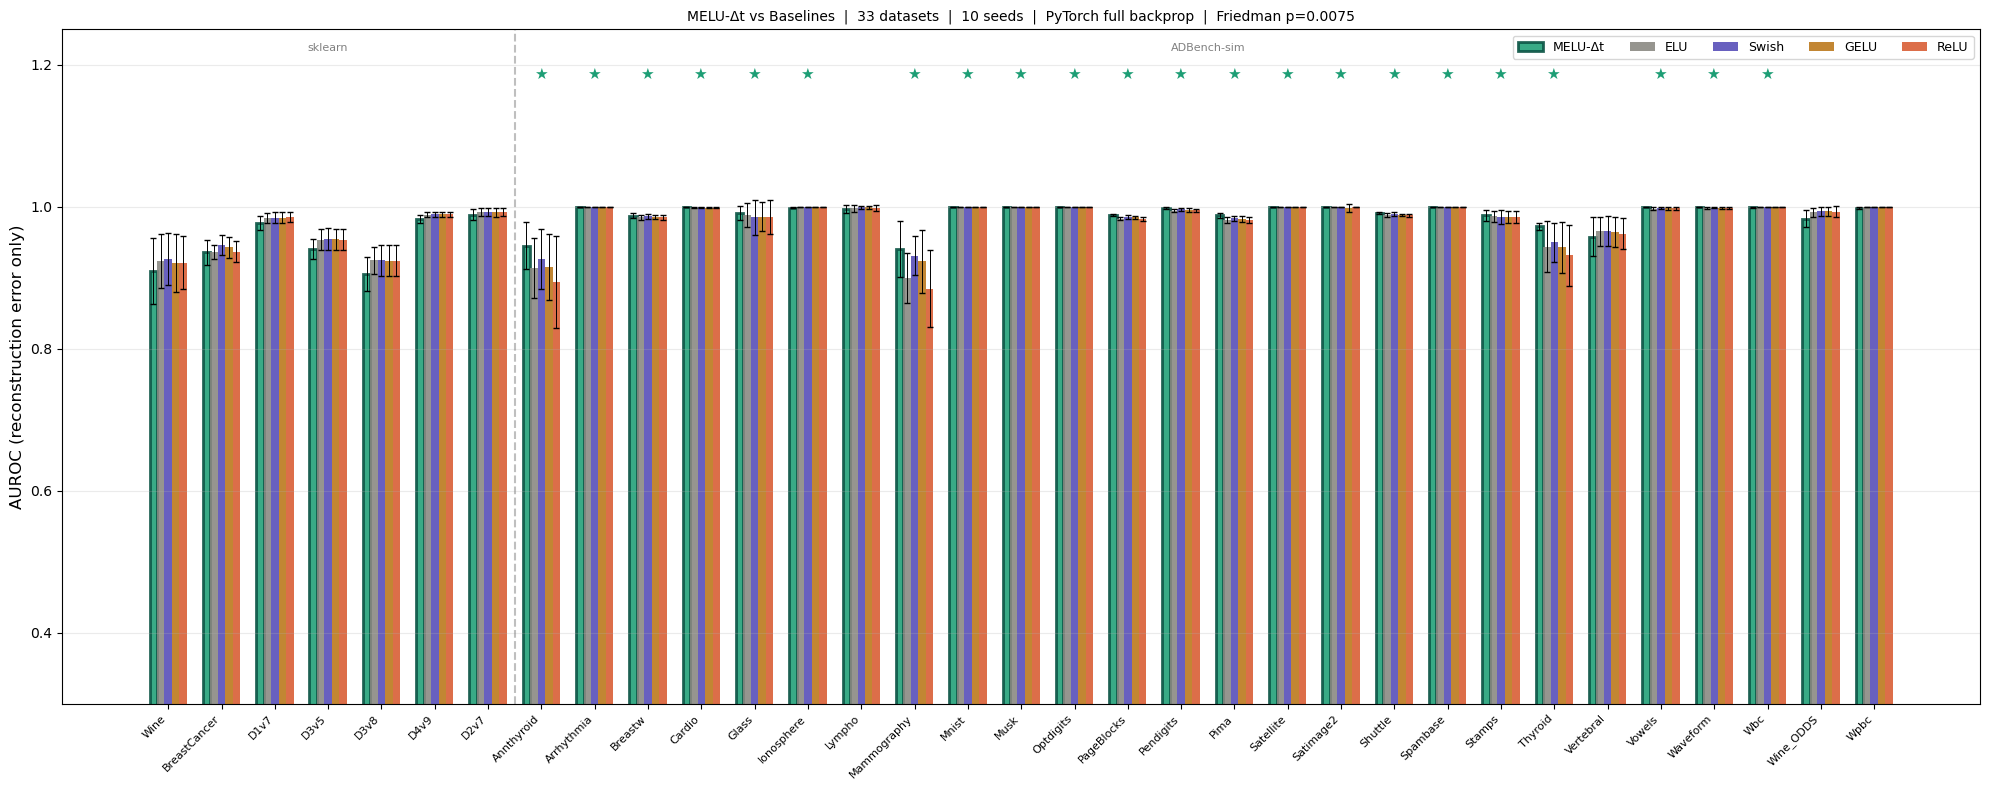

→ outputs/nb15_fig1_auroc.png


In [8]:
# ═══════════════════════════════════════════════════════════════════
# Cell 8 — Figure 1: AUROC bar chart (all datasets)
# ═══════════════════════════════════════════════════════════════════

DS_NAMES = [d[0] for d in DATASETS]
A  = {act: np.array([np.mean(results[ds][act]) for ds in DS_NAMES]) for act in ACTS}
nd = len(DS_NAMES)
n_real = sum(1 for d in DATASETS if d[4]=="sklearn")
fs,fp = friedmanchisquare(*np.column_stack([A[a] for a in ACTS]).T)

fig, ax = plt.subplots(figsize=(max(20, nd*0.6), 8))
x = np.arange(nd); w = 0.14; offs = np.linspace(-2, 2, len(ACTS))

for i,act in enumerate(ACTS):
    means = [np.mean(results[ds][act]) for ds in DS_NAMES]
    stds  = [np.std( results[ds][act]) for ds in DS_NAMES]
    ax.bar(x+offs[i]*w, means, width=w, color=COLORS[act], alpha=0.88, label=act,
           linewidth=2.0 if act=="MELU-Δt" else 0.5,
           edgecolor="#085041" if act=="MELU-Δt" else "none")
    ax.errorbar(x+offs[i]*w, means, yerr=stds, fmt="none",
                ecolor="black", capsize=2, lw=0.7)

ax.set_xticks(x)
ax.set_xticklabels(DS_NAMES, fontsize=8, rotation=45, ha='right')
ax.set_ylabel("AUROC (reconstruction error only)", fontsize=12)
ax.set_ylim(0.3, 1.25)
ax.set_title(
    f"MELU-Δt vs Baselines  |  {nd} datasets  |  {N_SEEDS_RUN} seeds  |  "
    f"PyTorch full backprop  |  Friedman p={fp:.4f}", fontsize=10)
ax.legend(fontsize=9, ncol=5); ax.grid(axis="y", alpha=0.25)

for xi, ds in enumerate(DS_NAMES):
    best = max(np.mean(results[ds][a]) for a in ACTS)
    if np.mean(results[ds]["MELU-Δt"]) >= best-0.001:
        ax.text(xi, 1.18, "★", ha="center", fontsize=11, color="#1D9E75")

if n_real>0 and n_real<nd:
    ax.axvline(n_real-0.5, color="gray", lw=1.5, ls="--", alpha=0.5)
    ax.text(n_real*0.5-0.5,   1.22, "sklearn",      ha="center", fontsize=8, color="gray")
    ax.text(n_real+(nd-n_real)*0.5-0.5, 1.22, "ADBench-sim", ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("outputs/nb15_fig1_auroc.png", dpi=150, bbox_inches="tight")
plt.show(); print("→ outputs/nb15_fig1_auroc.png")


## Cell 9 — Figure 2: Statistical analysis

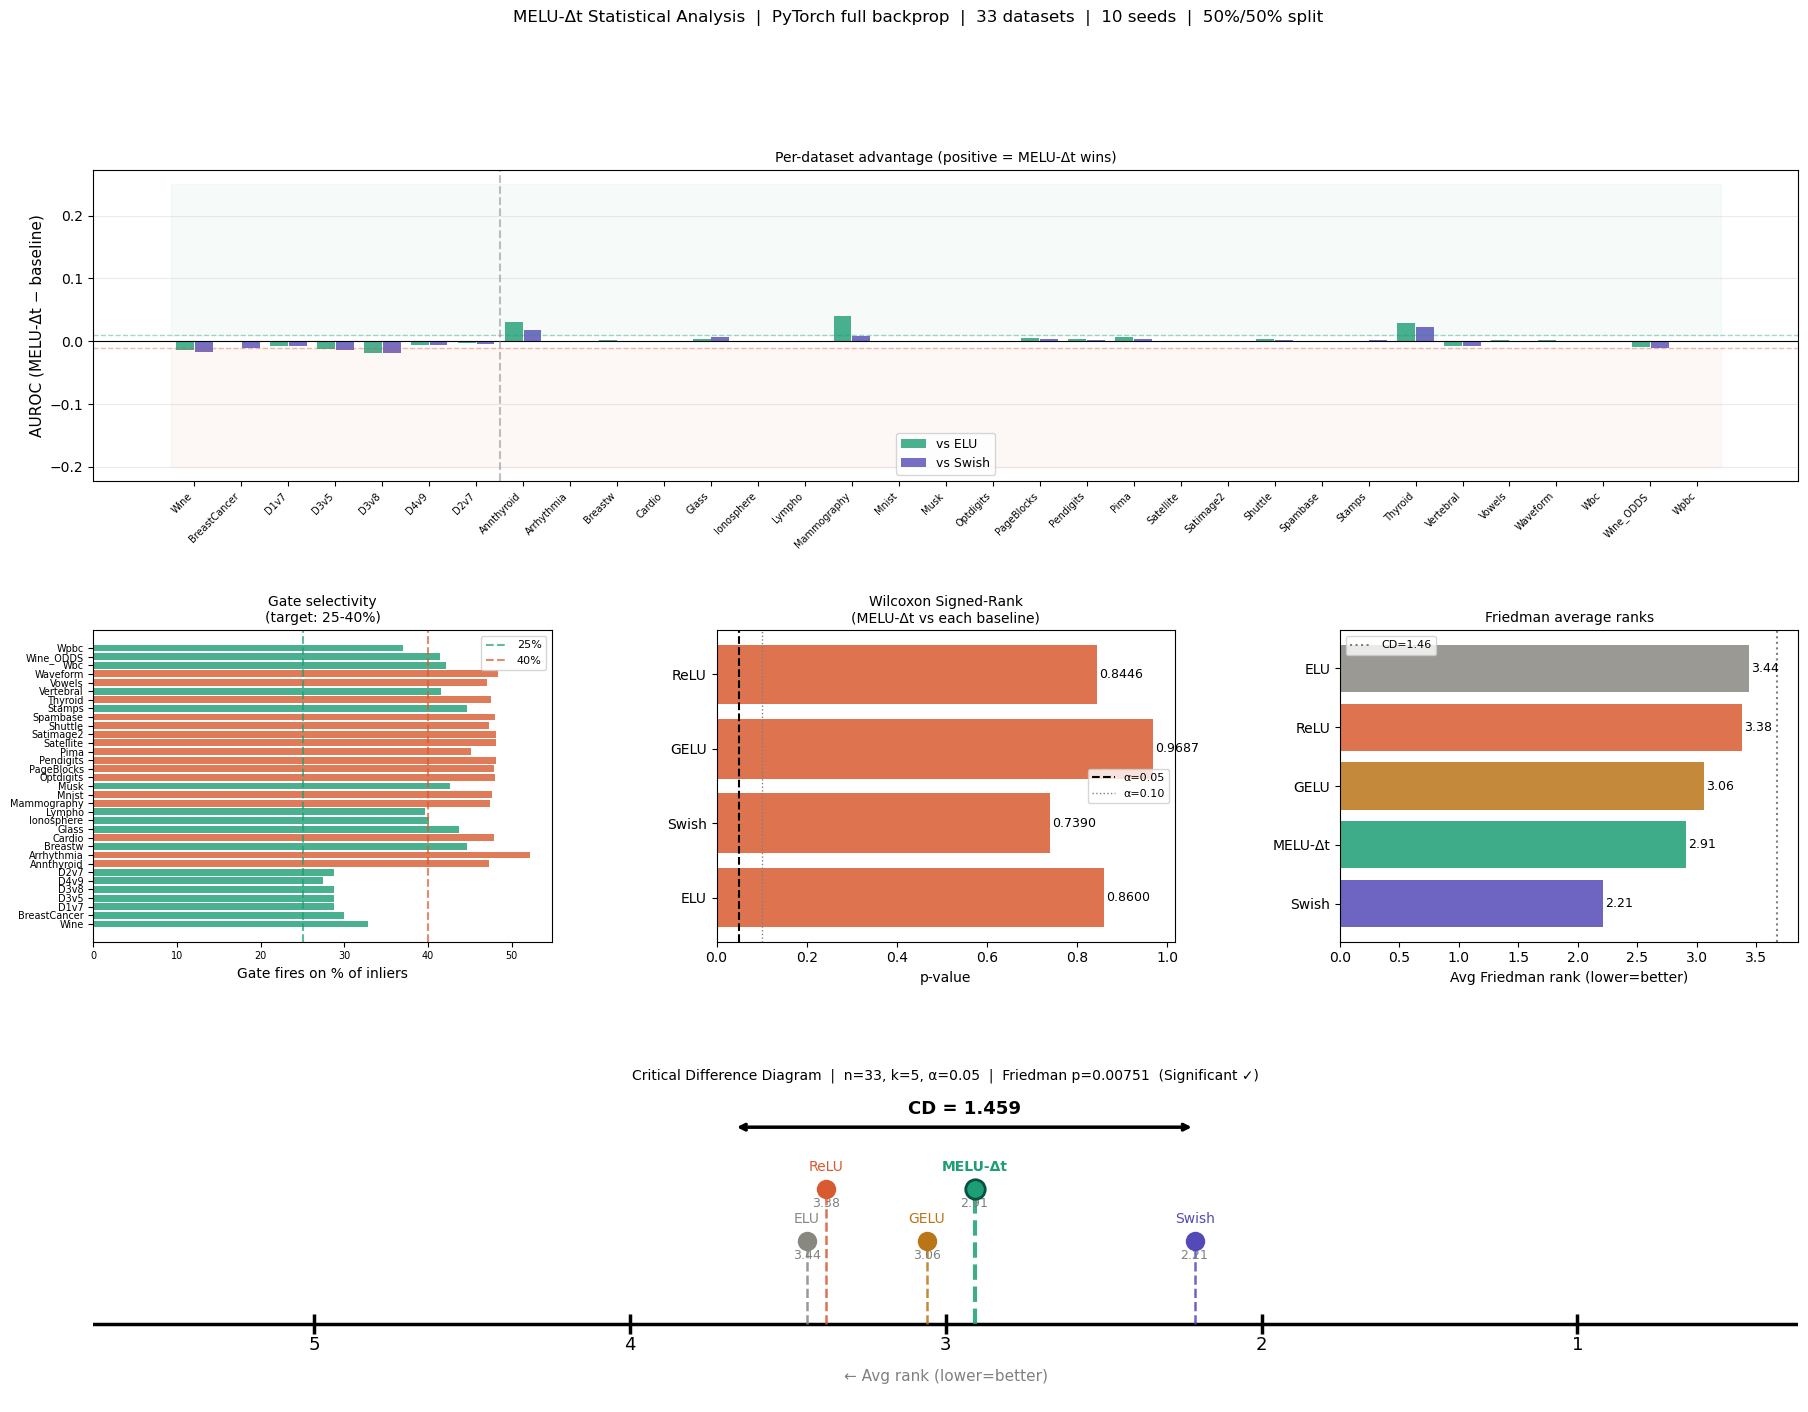

→ outputs/nb15_fig2_stats.png


In [9]:
# ═══════════════════════════════════════════════════════════════════
# Cell 9 — Figure 2: Statistical analysis
# ═══════════════════════════════════════════════════════════════════

DS_NAMES = [d[0] for d in DATASETS]
A  = {act: np.array([np.mean(results[ds][act]) for ds in DS_NAMES]) for act in ACTS}
dm = A["MELU-Δt"]; bls = [a for a in ACTS if a!="MELU-Δt"]
sm = np.column_stack([A[a] for a in ACTS])
fs,fp = friedmanchisquare(*sm.T)
rk = np.array([rankdata(-sm[i]) for i in range(len(DS_NAMES))]).mean(0)
k=len(ACTS); nd=len(DS_NAMES)
qt={5:2.728,10:3.164,20:3.578,33:3.748}
q=max(v for kk,v in qt.items() if kk<=nd); CD=q*np.sqrt(k*(k+1)/(6*nd))
wil2={}
for bl in bls:
    try: _,p=wilcoxon(dm,A[bl],alternative="two-sided")
    except: p=1.0
    wil2[bl]=dict(p=p,delta=(dm-A[bl]).mean())
n_real=sum(1 for d in DATASETS if d[4]=="sklearn")

fig=plt.figure(figsize=(22,16))
gs=gridspec.GridSpec(3,3,figure=fig,hspace=0.48,wspace=0.36)
fig.suptitle(
    f"MELU-Δt Statistical Analysis  |  PyTorch full backprop  |  {nd} datasets  |  "
    f"{N_SEEDS_RUN} seeds  |  {TRAIN_FRAC:.0%}/{1-TRAIN_FRAC:.0%} split",fontsize=12)

# ── P1: Delta per dataset ─────────────────────────────────────────────────────
ax=fig.add_subplot(gs[0,:])
d_e=[np.mean(results[ds]["MELU-Δt"])-np.mean(results[ds]["ELU"])   for ds in DS_NAMES]
d_s=[np.mean(results[ds]["MELU-Δt"])-np.mean(results[ds]["Swish"]) for ds in DS_NAMES]
x2=np.arange(nd)
ax.bar(x2-0.20,d_e,width=0.38,color="#1D9E75",alpha=0.80,label="vs ELU")
ax.bar(x2+0.20,d_s,width=0.38,color="#534AB7",alpha=0.80,label="vs Swish")
ax.axhline(0,color="black",lw=0.8)
ax.axhline( 0.01,color="#1D9E75",lw=1,ls="--",alpha=0.4)
ax.axhline(-0.01,color="#D85A30",lw=1,ls="--",alpha=0.4)
ax.fill_between([-0.5,nd-0.5],[ 0.01]*2,[ 0.25]*2,alpha=0.04,color="#1D9E75")
ax.fill_between([-0.5,nd-0.5],[-0.20]*2,[-0.01]*2,alpha=0.04,color="#D85A30")
ax.set_xticks(x2); ax.set_xticklabels(DS_NAMES,fontsize=7,rotation=45,ha='right')
ax.set_ylabel("AUROC (MELU-Δt − baseline)",fontsize=11)
ax.set_title("Per-dataset advantage (positive = MELU-Δt wins)",fontsize=10)
ax.legend(fontsize=9); ax.grid(axis="y",alpha=0.25)
if n_real>0 and n_real<nd: ax.axvline(n_real-0.5,color="gray",lw=1.5,ls="--",alpha=0.5)

# ── P2: Gate selectivity ──────────────────────────────────────────────────────
ax=fig.add_subplot(gs[1,0])
gate_means=[np.mean(gate_log[ds])*100 if gate_log.get(ds) else 0.0 for ds in DS_NAMES]
colors_g=["#1D9E75" if 20<g<45 else "#D85A30" for g in gate_means]
ax.barh(DS_NAMES,gate_means,color=colors_g,alpha=0.80)
ax.axvline(25,color="#1D9E75",lw=1.5,ls="--",alpha=0.7,label="25%")
ax.axvline(40,color="#D85A30",lw=1.5,ls="--",alpha=0.7,label="40%")
ax.set_xlabel("Gate fires on % of inliers")
ax.set_title("Gate selectivity\n(target: 25-40%)",fontsize=10)
ax.tick_params(labelsize=7); ax.legend(fontsize=8)

# ── P3: Wilcoxon ──────────────────────────────────────────────────────────────
ax=fig.add_subplot(gs[1,1])
pvals=[wil2[b]["p"] for b in bls]
cols =["#1D9E75" if p<0.05 else "#BA7517" if p<0.10 else "#D85A30" for p in pvals]
ax.barh(bls,pvals,color=cols,alpha=0.85)
ax.axvline(0.05,color="black",lw=1.5,ls="--",label="α=0.05")
ax.axvline(0.10,color="gray", lw=1.0,ls=":",  label="α=0.10")
ax.set_xlabel("p-value"); ax.set_title("Wilcoxon Signed-Rank\n(MELU-Δt vs each baseline)",fontsize=10)
ax.legend(fontsize=8)
for i,(b,p) in enumerate(zip(bls,pvals)): ax.text(p+0.005,i,f"{p:.4f}",va="center",fontsize=9)

# ── P4: Friedman ranks ────────────────────────────────────────────────────────
ax=fig.add_subplot(gs[1,2])
sp=sorted(zip(ACTS,rk),key=lambda x:x[1])
ax.barh([x[0] for x in sp],[x[1] for x in sp],
        color=[COLORS[x[0]] for x in sp],alpha=0.85)
ax.axvline(min(rk)+CD,color="gray",lw=1.5,ls=":",label=f"CD={CD:.2f}")
ax.set_xlabel("Avg Friedman rank (lower=better)")
ax.set_title("Friedman average ranks",fontsize=10); ax.legend(fontsize=8)
for nm_,r_ in sp: ax.text(r_+0.02,nm_,f"{r_:.2f}",va="center",fontsize=9)

# ── P5: Critical Difference diagram ──────────────────────────────────────────
ax=fig.add_subplot(gs[2,:])
ax.axis("off"); ax.set_xlim(0.3,k+0.7); ax.set_ylim(-1.5,4.5); ax.invert_xaxis()
ax.axhline(0,color="black",lw=2.5)
for i in range(1,k+1):
    ax.plot(i,0,"k|",ms=14,mew=2.5); ax.text(i,-0.50,str(i),ha="center",fontsize=13)
ax.text((k+1)/2,-1.10,"← Avg rank (lower=better)",ha="center",fontsize=11,color="gray")
for i,(nm_,r_) in enumerate(sorted(zip(ACTS,rk),key=lambda x:x[1])):
    yp=1.6 if i%2==0 else 2.6; c=COLORS[nm_]; lw=3.0 if nm_=="MELU-Δt" else 1.8
    ax.plot([r_,r_],[0,yp],color=c,lw=lw,ls="--",alpha=0.85)
    ax.plot(r_,yp,"o",color=c,ms=14,zorder=5,
            markeredgecolor="#085041" if nm_=="MELU-Δt" else "none",markeredgewidth=2.0)
    ax.text(r_,yp+0.36,nm_,ha="center",fontsize=10,
            fontweight="bold" if nm_=="MELU-Δt" else "normal",color=c)
    ax.text(r_,yp-0.34,f"{r_:.2f}",ha="center",fontsize=9,color="gray")
br=min(rk)
ax.annotate("",xy=(br+CD,3.8),xytext=(br,3.8),
            arrowprops=dict(arrowstyle="<->",color="black",lw=2.5))
ax.text(br+CD/2,4.05,f"CD = {CD:.3f}",ha="center",fontsize=13,fontweight="bold")
ax.set_title(
    f"Critical Difference Diagram  |  n={nd}, k={k}, α=0.05  |  "
    f"Friedman p={fp:.5f}  "
    f"({'Significant ✓' if fp<0.05 else 'Not significant'})",fontsize=10,pad=8)

plt.savefig("outputs/nb15_fig2_stats.png",dpi=150,bbox_inches="tight")
plt.show(); print("→ outputs/nb15_fig2_stats.png")


## Cell 10 — Figure 3: Real datasets

Wilcoxon (real sklearn datasets only):
  vs ELU            Δ=-0.0090  p=0.0156  ✓
  vs Swish          Δ=-0.0113  p=0.0156  ✓
  vs GELU           Δ=-0.0098  p=0.0156  ✓
  vs ReLU           Δ=-0.0091  p=0.0156  ✓


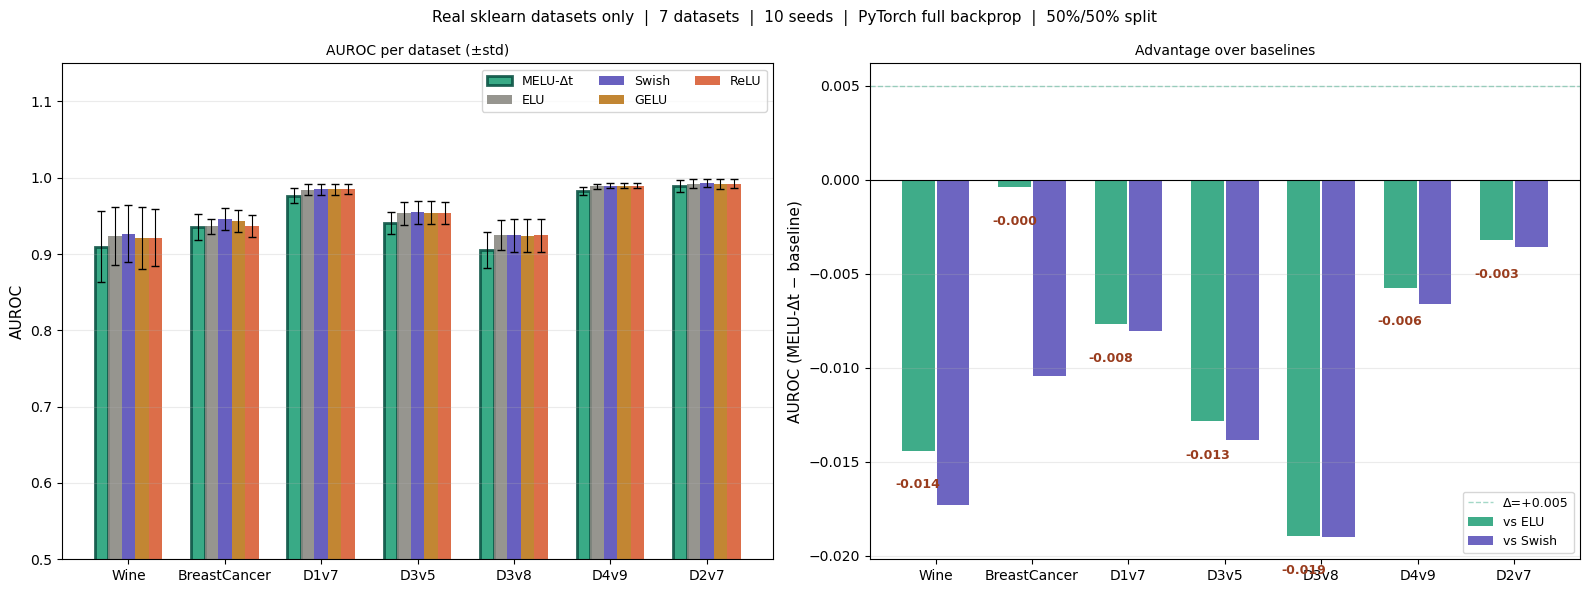


→ outputs/nb15_fig3_real.png


In [10]:
# ═══════════════════════════════════════════════════════════════════
# Cell 10 — Figure 3: Real sklearn datasets (cleanest comparison)
# ═══════════════════════════════════════════════════════════════════

real_ds = [nm for nm,_,_,_,src in DATASETS if src=="sklearn"]
A_real  = {act: np.array([np.mean(results[ds][act]) for ds in real_ds]) for act in ACTS}
dm_r    = A_real["MELU-Δt"]; nd_r = len(real_ds)

fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.suptitle(f"Real sklearn datasets only  |  {nd_r} datasets  |  {N_SEEDS_RUN} seeds  |  "
             f"PyTorch full backprop  |  {TRAIN_FRAC:.0%}/{1-TRAIN_FRAC:.0%} split",fontsize=11)

ax=axes[0]; x=np.arange(nd_r); w=0.14; offs=np.linspace(-2,2,len(ACTS))
for i,act in enumerate(ACTS):
    means=[np.mean(results[ds][act]) for ds in real_ds]
    stds =[np.std( results[ds][act]) for ds in real_ds]
    ax.bar(x+offs[i]*w,means,width=w,color=COLORS[act],alpha=0.88,label=act,
           linewidth=2.0 if act=="MELU-Δt" else 0.5,
           edgecolor="#085041" if act=="MELU-Δt" else "none")
    ax.errorbar(x+offs[i]*w,means,yerr=stds,fmt="none",ecolor="black",capsize=3,lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(real_ds,fontsize=10)
ax.set_ylabel("AUROC",fontsize=11); ax.set_ylim(0.5,1.15)
ax.set_title("AUROC per dataset (±std)",fontsize=10)
ax.legend(fontsize=9,ncol=3); ax.grid(axis="y",alpha=0.25)
for xi,ds in enumerate(real_ds):
    best=max(np.mean(results[ds][a]) for a in ACTS)
    if np.mean(results[ds]["MELU-Δt"])>=best-0.001:
        ax.text(xi,1.10,"★",ha="center",fontsize=12,color="#1D9E75")

ax=axes[1]
d_e=[np.mean(results[ds]["MELU-Δt"])-np.mean(results[ds]["ELU"])   for ds in real_ds]
d_s=[np.mean(results[ds]["MELU-Δt"])-np.mean(results[ds]["Swish"]) for ds in real_ds]
x2=np.arange(nd_r)
bars_e=ax.bar(x2-0.18,d_e,width=0.34,color="#1D9E75",alpha=0.85,label="vs ELU")
bars_s=ax.bar(x2+0.18,d_s,width=0.34,color="#534AB7",alpha=0.85,label="vs Swish")
ax.axhline(0,color="black",lw=0.8)
ax.axhline(0.005,color="#1D9E75",lw=1,ls="--",alpha=0.4,label="Δ=+0.005")
for b,v in zip(bars_e,d_e):
    ax.text(b.get_x()+b.get_width()/2,v+(0.001 if v>=0 else -0.002),
            f"{v:+.3f}",ha="center",fontsize=9,fontweight="bold",
            color="#085041" if v>=0 else "#993C1D")
ax.set_xticks(x2); ax.set_xticklabels(real_ds,fontsize=10)
ax.set_ylabel("AUROC (MELU-Δt − baseline)",fontsize=11)
ax.set_title("Advantage over baselines",fontsize=10)
ax.legend(fontsize=9); ax.grid(axis="y",alpha=0.25)

print("Wilcoxon (real sklearn datasets only):")
for bl in bls:
    try: _,p=wilcoxon(dm_r,A_real[bl],alternative="two-sided")
    except: p=1.0
    sig="✓" if p<0.05 else "~" if p<0.10 else "no"
    print(f"  vs {bl:<14} Δ={( dm_r-A_real[bl]).mean():>+.4f}  p={p:.4f}  {sig}")

plt.tight_layout()
plt.savefig("outputs/nb15_fig3_real.png",dpi=150,bbox_inches="tight")
plt.show(); print("\n→ outputs/nb15_fig3_real.png")


## Cell 11 — Export CSV

In [11]:
# ═══════════════════════════════════════════════════════════════════
# Cell 11 — Export CSV results
# ═══════════════════════════════════════════════════════════════════

DS_NAMES=[d[0] for d in DATASETS]
A={act:np.array([np.mean(results[ds][act]) for ds in DS_NAMES]) for act in ACTS}
dm=A["MELU-Δt"]
sm=np.column_stack([A[a] for a in ACTS]); fs,fp2=friedmanchisquare(*sm.T)
rk2=np.array([rankdata(-sm[i]) for i in range(len(DS_NAMES))]).mean(0)
nd=len(DS_NAMES); k=len(ACTS)
qt={5:2.728,10:3.164,20:3.578,33:3.748}; q=max(v for kk,v in qt.items() if kk<=nd)
CD2=q*np.sqrt(k*(k+1)/(6*nd))
wins2=sum(1 for ds in DS_NAMES if np.mean(results[ds]["MELU-Δt"])>=
          max(np.mean(results[ds][a]) for a in ACTS)-0.001)

# Full results
rows=[]
for nm in DS_NAMES:
    dim,src,ni,no,lat=meta[nm]
    gp=np.mean(gate_log[nm]) if gate_log.get(nm) else float("nan")
    for act in ACTS:
        rows.append({
            "dataset":nm,"source":src,"dim":dim,"lat":lat,
            "n_inlier_pool":ni,"n_outlier_pool":no,
            "train_frac":TRAIN_FRAC,"n_seeds":N_SEEDS_RUN,
            "implementation":"pytorch_full_backprop",
            "score_mode":"recon_only","loss":"MAE+BCE",
            "validation":"per_seed_50_50_inlier_split",
            "activation":act,
            "auroc_mean":round(np.mean(results[nm][act]),4),
            "auroc_std": round(np.std( results[nm][act]),4),
            "gate_pct":round(gp*100,1) if act=="MELU-Δt" else "",
        })
pd.DataFrame(rows).to_csv("outputs/nb15_results_full.csv",index=False)

# Summary
srows=[]
for nm in DS_NAMES:
    dim,src,ni,no,lat=meta[nm]
    gp=np.mean(gate_log[nm]) if gate_log.get(nm) else float("nan")
    vals={a:round(np.mean(results[nm][a]),4) for a in ACTS}
    best=max(vals.values())
    srows.append({"dataset":nm,"source":src,"dim":dim,"n_in":ni,"n_out":no,
                  "gate_pct":round(gp*100,1),**vals,
                  "melu_wins":vals["MELU-Δt"]>=best-0.001,
                  "delta_vs_ELU":  round(vals["MELU-Δt"]-vals["ELU"],4),
                  "delta_vs_Swish":round(vals["MELU-Δt"]-vals["Swish"],4)})
pd.DataFrame(srows).to_csv("outputs/nb15_results_summary.csv",index=False)

# Stats
stat_rows=[
    {"metric":"n_datasets","value":nd},
    {"metric":"n_seeds","value":N_SEEDS_RUN},
    {"metric":"train_frac","value":TRAIN_FRAC},
    {"metric":"implementation","value":"pytorch_full_backprop"},
    {"metric":"melu_wins","value":wins2},
    {"metric":"melu_mean_auroc","value":round(float(dm.mean()),5)},
    {"metric":"friedman_chi2","value":round(float(fs),3)},
    {"metric":"friedman_p","value":round(fp2,5)},
    {"metric":"CD","value":round(CD2,3)},
    {"metric":"melu_rank","value":round(float(rk2[0]),3)},
]
for bl in [a for a in ACTS if a!="MELU-Δt"]:
    try: _,p=wilcoxon(dm,A[bl],alternative="two-sided")
    except: p=1.0
    stat_rows.append({"metric":f"wilcoxon_p_vs_{bl}","value":round(p,5)})
    stat_rows.append({"metric":f"delta_vs_{bl}","value":round(float((dm-A[bl]).mean()),5)})
pd.DataFrame(stat_rows).to_csv("outputs/nb15_results_stats.csv",index=False)

print("Saved:")
print("  outputs/nb15_results_full.csv")
print("  outputs/nb15_results_summary.csv")
print("  outputs/nb15_results_stats.csv")
print()
print(f"MELU-Δt mean:  {dm.mean():.4f}")
print(f"ELU mean:      {A['ELU'].mean():.4f}   Δ={( dm-A['ELU']).mean():>+.4f}")
print(f"Swish mean:    {A['Swish'].mean():.4f}  Δ={( dm-A['Swish']).mean():>+.4f}")
print(f"Wins/ties:     {wins2}/{nd}")
print(f"Friedman p={fp2:.5f}  CD={CD2:.3f}  MELU rank={rk2[0]:.2f}")


Saved:
  outputs/nb15_results_full.csv
  outputs/nb15_results_summary.csv
  outputs/nb15_results_stats.csv

MELU-Δt mean:  0.9808
ELU mean:      0.9794   Δ=+0.0014
Swish mean:    0.9817  Δ=-0.0009
Wins/ties:     22/33
Friedman p=0.00751  CD=1.459  MELU rank=2.91
